# Trabalho Final - notebook base do projeto da Asheley

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Pergunta de pesquisa

#### **As diferentes plataformas estão associadas a padrões diferentes de uso?**

(plataforma principal, tempo de uso, propósito, tempo de tela antes de dormir, média de minutos por sessão, nível de adicção)

O conjunto de dados Gen-Z Social Media Usage Dataset é um conjunto de dados sintético de grande escala, porém comportamentalmente realista, projetado para modelar como indivíduos de 13 a 27 anos interagem com plataformas de mídia social no ecossistema digital moderno.
Os dados são gerados usando distribuições estatisticamente fundamentadas e incorporam correlações realistas entre variáveis ​​como tempo de tela, preferência de plataforma e bem-estar mental.

In [11]:
df = pd.read_csv('../datasets/asheley/genz_social_media_usage_1M.zip')

df.head()

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


## Classificação das variáveis associadas à pergunta de pesquisa

In [32]:
print('Colunas presente no dataset: ',df.columns)

Colunas presente no dataset:  Index(['age', 'gender', 'country', 'daily_usage_hours', 'primary_platform',
       'num_platforms_used', 'purpose', 'avg_session_minutes', 'night_usage',
       'mental_health_score', 'addiction_level', 'screen_time_before_sleep'],
      dtype='object')


In [29]:
print('Variáveis categóricas')
print('Plataforma principal valores únicos: ',df.primary_platform.unique())
print('Propósito valores únicos: ', df['purpose'].unique())

print('\nVariáveis numéricas')
print('Distribuição dos valores em  tempo de tela antes de dormir: min:', df['screen_time_before_sleep'].min(), 'média:', df['screen_time_before_sleep'].mean(), 'max:', df['screen_time_before_sleep'].max())
print('Distribuição dos valores em  tempo de tela por dia: min:', df['daily_usage_hours'].min(), 'média:', df['daily_usage_hours'].mean(), 'max:', df['daily_usage_hours'].max())
print('Distribuição dos valores em  média de minutos por sessão: min:', df['avg_session_minutes'].min(), 'média:', df['avg_session_minutes'].mean(), 'max:', df['avg_session_minutes'].max())

Variáveis categóricas
Plataforma principal valores únicos:  ['Snapchat' 'Twitter' 'TikTok' 'YouTube' 'Instagram']
Propósito valores únicos:  ['Education' 'Socializing' 'Entertainment' 'News' 'Content Creation']

Variáveis numéricas
Distribuição dos valores em  tempo de tela antes de dormir: min: 0.0 média: 40.12075351426827 max: 137.9987192681989
Distribuição dos valores em  tempo de tela por dia: min: 0.5 média: 3.51499839429309 max: 10.0
Distribuição dos valores em  média de minutos por sessão: min: 5.0 média: 25.0888192478024 max: 80.26222433908394


As colunas selecionadas para contribuir para a análise final foram:
* plataforma principal: coluna categórica com 5 valores distintos, define a principal plataforma do usuário
* tempo de uso: coluna numérica, mede em minutos o uso diário nas redes sociais do usuário
* propósito: coluna categórica com 5 valores distintos, mapea o propósito de intenção que o usuário têm com sua palataforma principal
* tempo de tela antes de dormir: coluna numérica, mede o tempo de tela do usuário antes de dormir
* média de minutos por sessão: coluna numérica, mede em minutos a média de tempo em cada sessão de uso
* nível de adicção: coluna categórica com 3 valores distintos, mapea o nível de dependência de uso de redes sociais

O critério de seleção das variáveis foi a relevância e contribuição das colunas para responder a pergunta de pesquisa

## Verificando a qualidade dos dados

In [34]:
print('Número de linhas duplicadas no dataset: ', df.duplicated().sum())

Número de linhas duplicadas no dataset:  0


In [35]:
dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({"Dados faltantes (soma)": dados_faltantes_soma, "Dados faltantes (porcentagem)": dados_faltantes_porc})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
age,0,0.0
gender,0,0.0
country,0,0.0
daily_usage_hours,0,0.0
primary_platform,0,0.0
num_platforms_used,0,0.0
purpose,0,0.0
avg_session_minutes,0,0.0
night_usage,0,0.0
mental_health_score,0,0.0


Após as verificações concluímos que o dataset esta bem preenchido e adequado para uso de análise usando as colunas selecionados. A completude do dado também se deve a natureza do dataset, são dados sintéticos logo toda e qualquer registro tem um valor esperado e preenchido. Assim não se faz necessária limpeza de dados.

## Estatística descritiva

In [44]:
# Criando subconjuntos de dados por plataforma
df_snap = df[df.primary_platform == 'Snapchat']
df_twitter = df[df.primary_platform == 'Twitter']
df_tiktok = df[df.primary_platform == 'TikTok']
df_youtube = df[df.primary_platform == 'YouTube']
df_instagram = df[df.primary_platform == 'Instagram']

# Criando subconjuntos de dados por propósito
df_education = df[df.purpose == 'Education']
df_socializing = df[df.purpose == 'Socializing']
df_entertainment = df[df.purpose == 'Entertainment']
df_news = df[df.purpose == 'News']
df_content_creation = df[df.purpose == 'Content Creation']


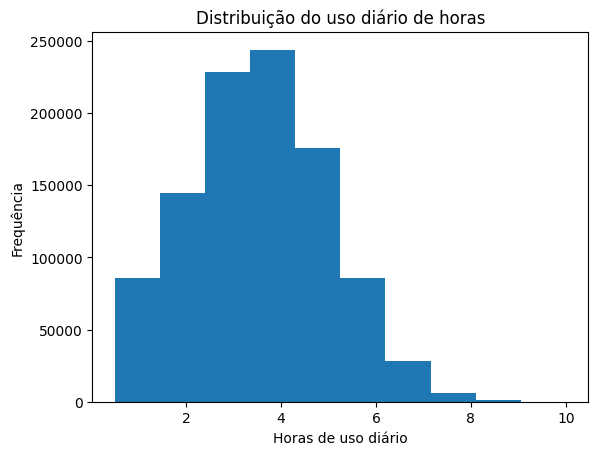

In [39]:
plt.hist(df.daily_usage_hours)
plt.xlabel('Horas de uso diário')
plt.ylabel('Frequência')
plt.title('Distribuição do uso diário de horas')
plt.show()

### Análise por plataforma

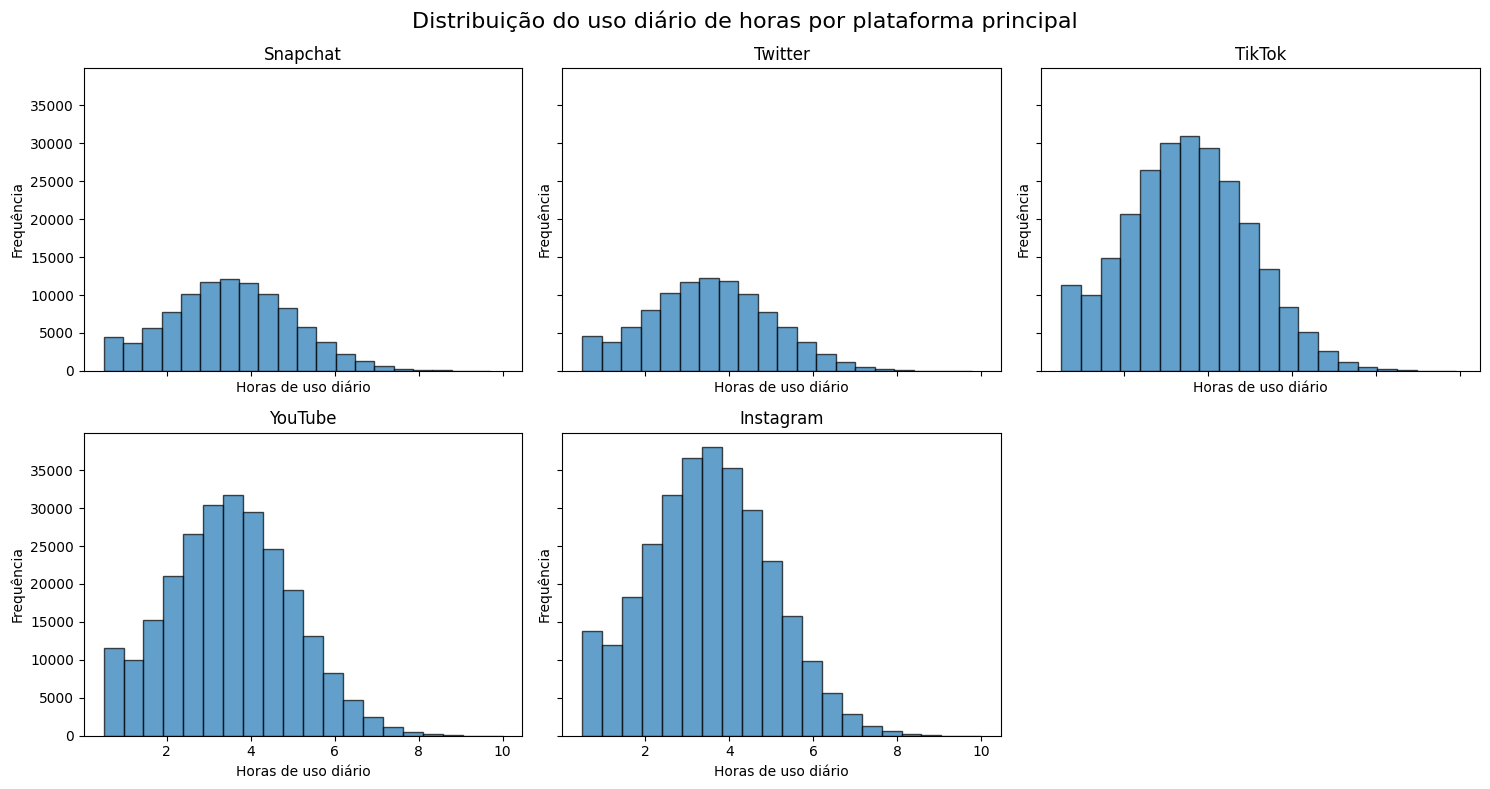

In [43]:
# Visualização da distribuição do uso diário de horas por plataforma em subplots
plataformas = [
    ('Snapchat', df_snap),
    ('Twitter', df_twitter),
    ('TikTok', df_tiktok),
    ('YouTube', df_youtube),
    ('Instagram', df_instagram)
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (nome, df_plat) in enumerate(plataformas):
    axes[i].hist(df_plat['daily_usage_hours'], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(nome)
    axes[i].set_xlabel('Horas de uso diário')
    axes[i].set_ylabel('Frequência')

# Remover o sexto subplot que não é utilizado
fig.delaxes(axes[5])

plt.suptitle('Distribuição do uso diário de horas por plataforma principal', fontsize=16)
plt.tight_layout()
plt.show()

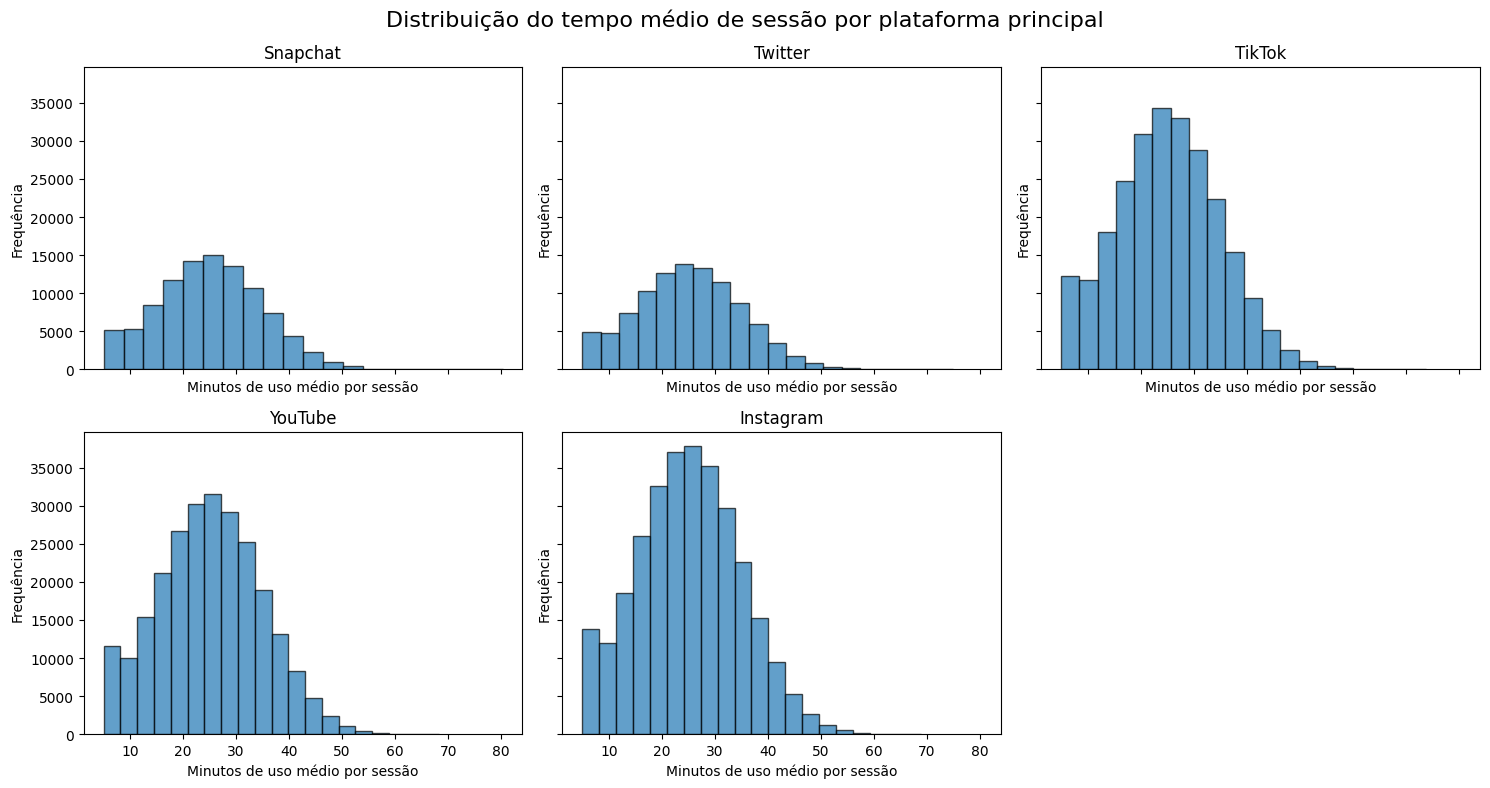

In [47]:
# Visualização da distribuição do uso diário de horas por plataforma em subplots
plataformas = [
    ('Snapchat', df_snap),
    ('Twitter', df_twitter),
    ('TikTok', df_tiktok),
    ('YouTube', df_youtube),
    ('Instagram', df_instagram)
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (nome, df_plat) in enumerate(plataformas):
    axes[i].hist(df_plat['avg_session_minutes'], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(nome)
    axes[i].set_xlabel('Minutos de uso médio por sessão')
    axes[i].set_ylabel('Frequência')

# Remover o sexto subplot que não é utilizado
fig.delaxes(axes[5])

plt.suptitle('Distribuição do tempo médio de sessão por plataforma principal', fontsize=16)
plt.tight_layout()
plt.show()

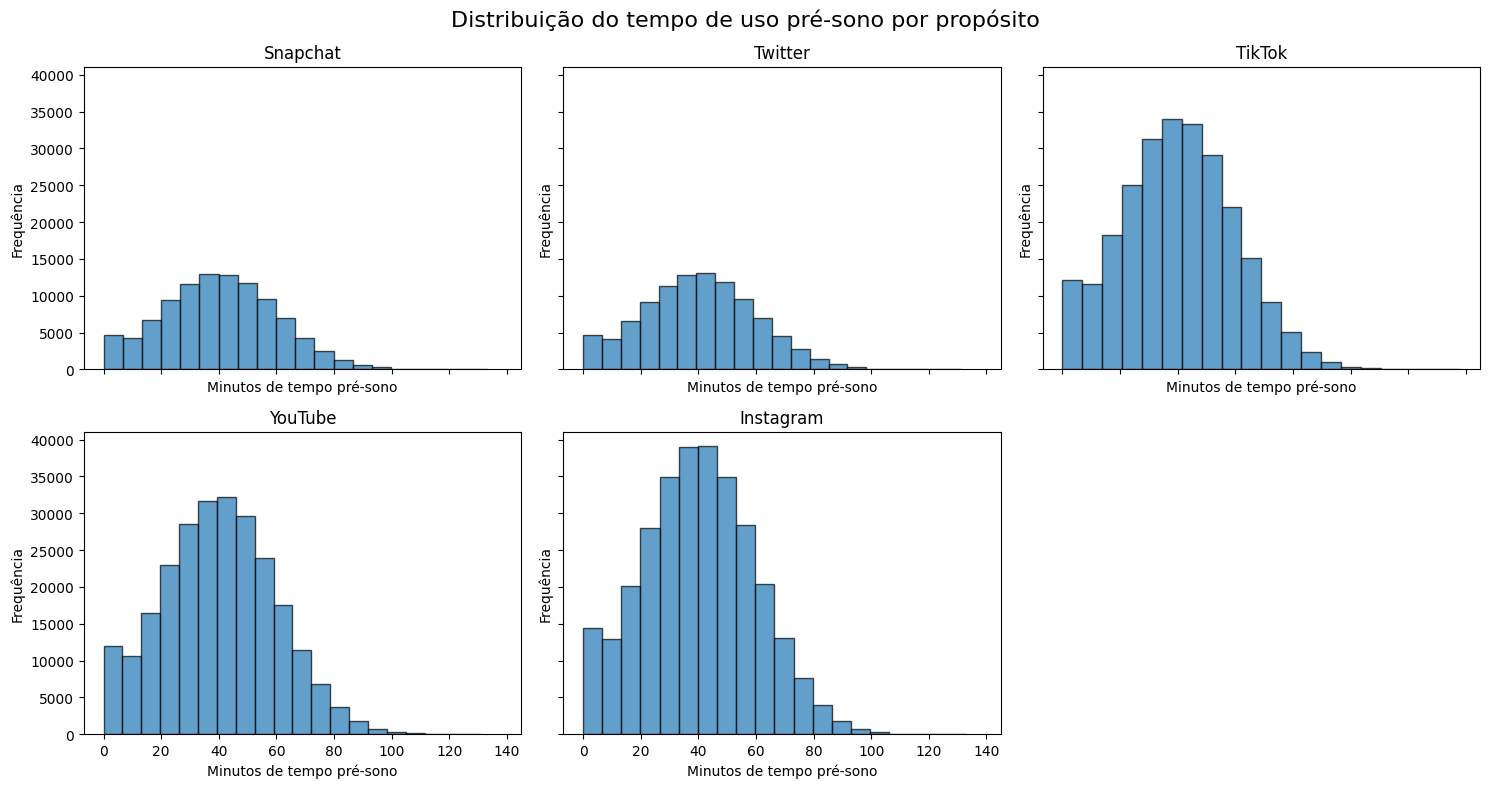

In [65]:
# Visualização da distribuição do uso diário de horas por plataforma em subplots

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (nome, df_plat) in enumerate(plataformas):
    axes[i].hist(df_plat['screen_time_before_sleep'], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(nome)
    axes[i].set_xlabel('Minutos de tempo pré-sono')
    axes[i].set_ylabel('Frequência')

# Remover o sexto subplot que não é utilizado
fig.delaxes(axes[5])
    
plt.suptitle('Distribuição do tempo de uso pré-sono por propósito', fontsize=16)
plt.tight_layout()
plt.show()

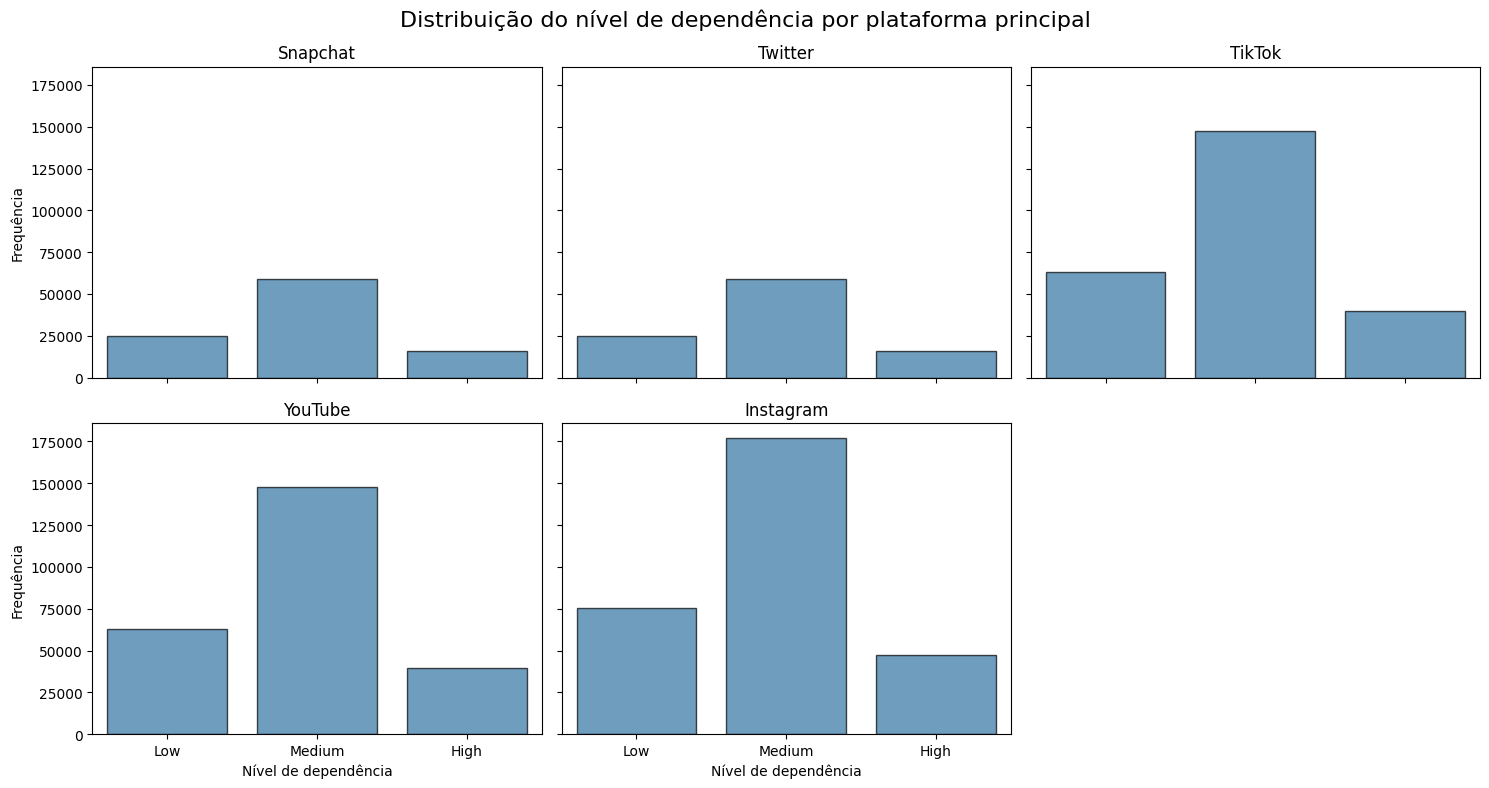

In [55]:
# Nível de dependência por plataforma 
ordem_addiction = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (nome, df_plat) in enumerate(plataformas):
    sns.countplot(x='addiction_level', data=df_plat, order=ordem_addiction, edgecolor='black', alpha=0.7, ax=axes[i])
    axes[i].set_title(nome)
    axes[i].set_xlabel('Nível de dependência')
    axes[i].set_ylabel('Frequência')

fig.delaxes(axes[5])

plt.suptitle('Distribuição do nível de dependência por plataforma principal', fontsize=16)
plt.tight_layout()
plt.show()

### Análise por propósito

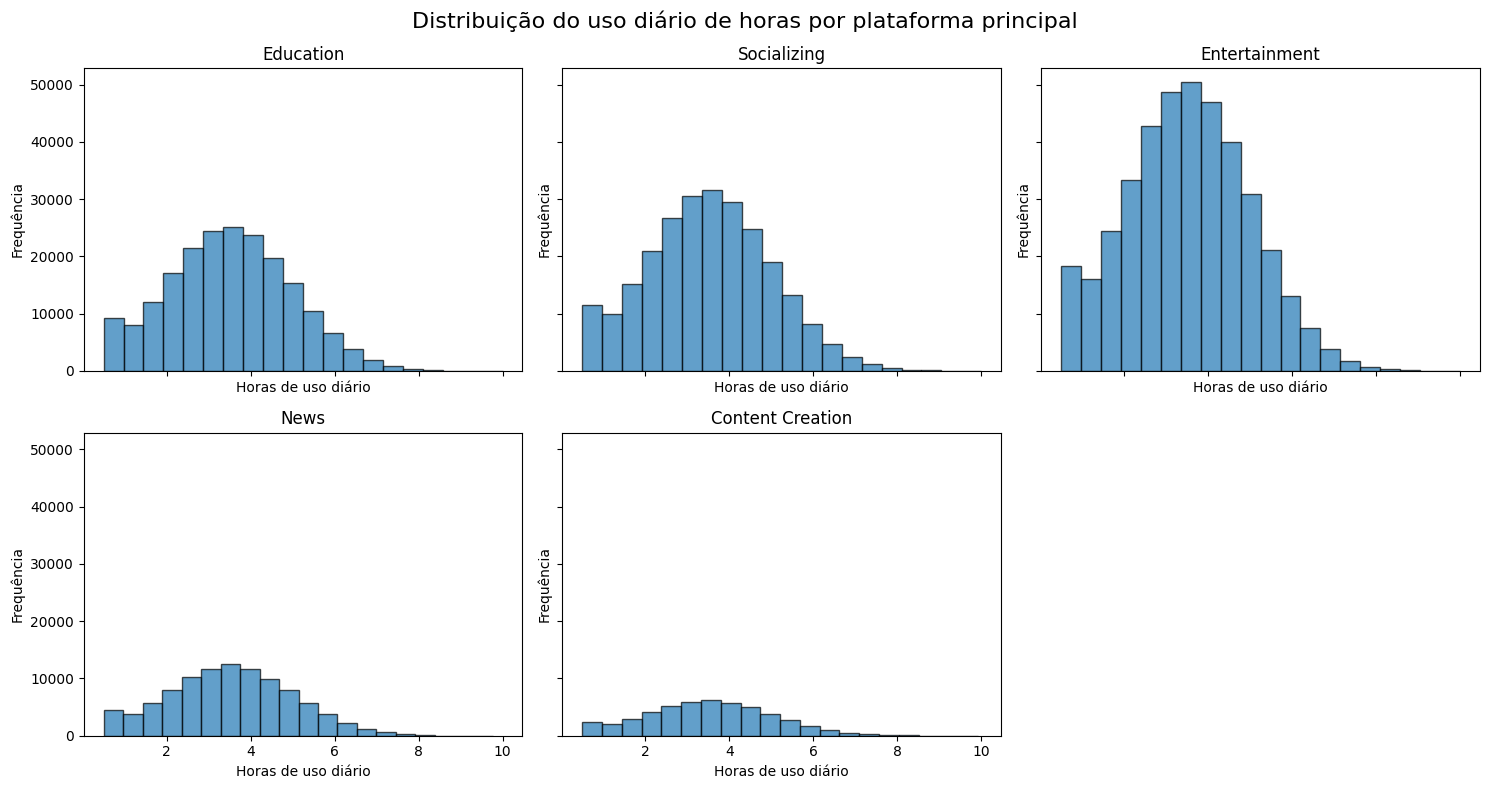

In [45]:
# Visualização da distribuição do uso diário de horas por plataforma em subplots
['Education' 'Socializing' 'Entertainment' 'News' 'Content Creation']
propositos = [
    ('Education', df_education),
    ('Socializing', df_socializing),
    ('Entertainment', df_entertainment),
    ('News', df_news),
    ('Content Creation', df_content_creation)
]


fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (nome, df_plat) in enumerate(propositos):
    axes[i].hist(df_plat['daily_usage_hours'], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(nome)
    axes[i].set_xlabel('Horas de uso diário')
    axes[i].set_ylabel('Frequência')

# Remover o sexto subplot que não é utilizado
fig.delaxes(axes[5])

plt.suptitle('Distribuição do uso diário de horas por propósito', fontsize=16)
plt.tight_layout()
plt.show()

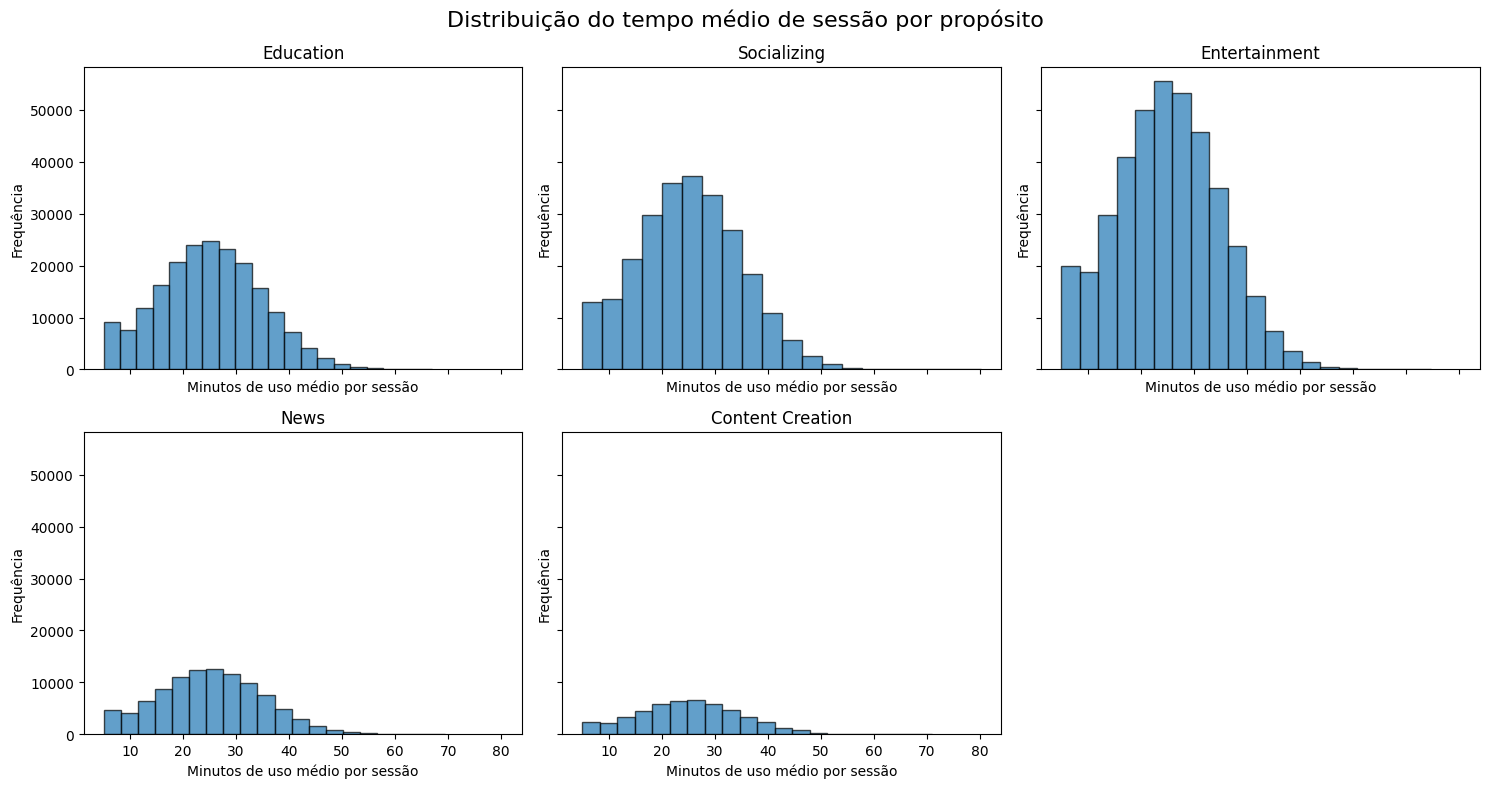

In [49]:
# Visualização da distribuição do uso diário de horas por plataforma em subplots
['Education' 'Socializing' 'Entertainment' 'News' 'Content Creation']
propositos = [
    ('Education', df_education),
    ('Socializing', df_socializing),
    ('Entertainment', df_entertainment),
    ('News', df_news),
    ('Content Creation', df_content_creation)
]


fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (nome, df_plat) in enumerate(propositos):
    axes[i].hist(df_plat['avg_session_minutes'], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(nome)
    axes[i].set_xlabel('Minutos de uso médio por sessão')
    axes[i].set_ylabel('Frequência')

# Remover o sexto subplot que não é utilizado
fig.delaxes(axes[5])

plt.suptitle('Distribuição do tempo médio de sessão por propósito', fontsize=16)
plt.tight_layout()
plt.show()

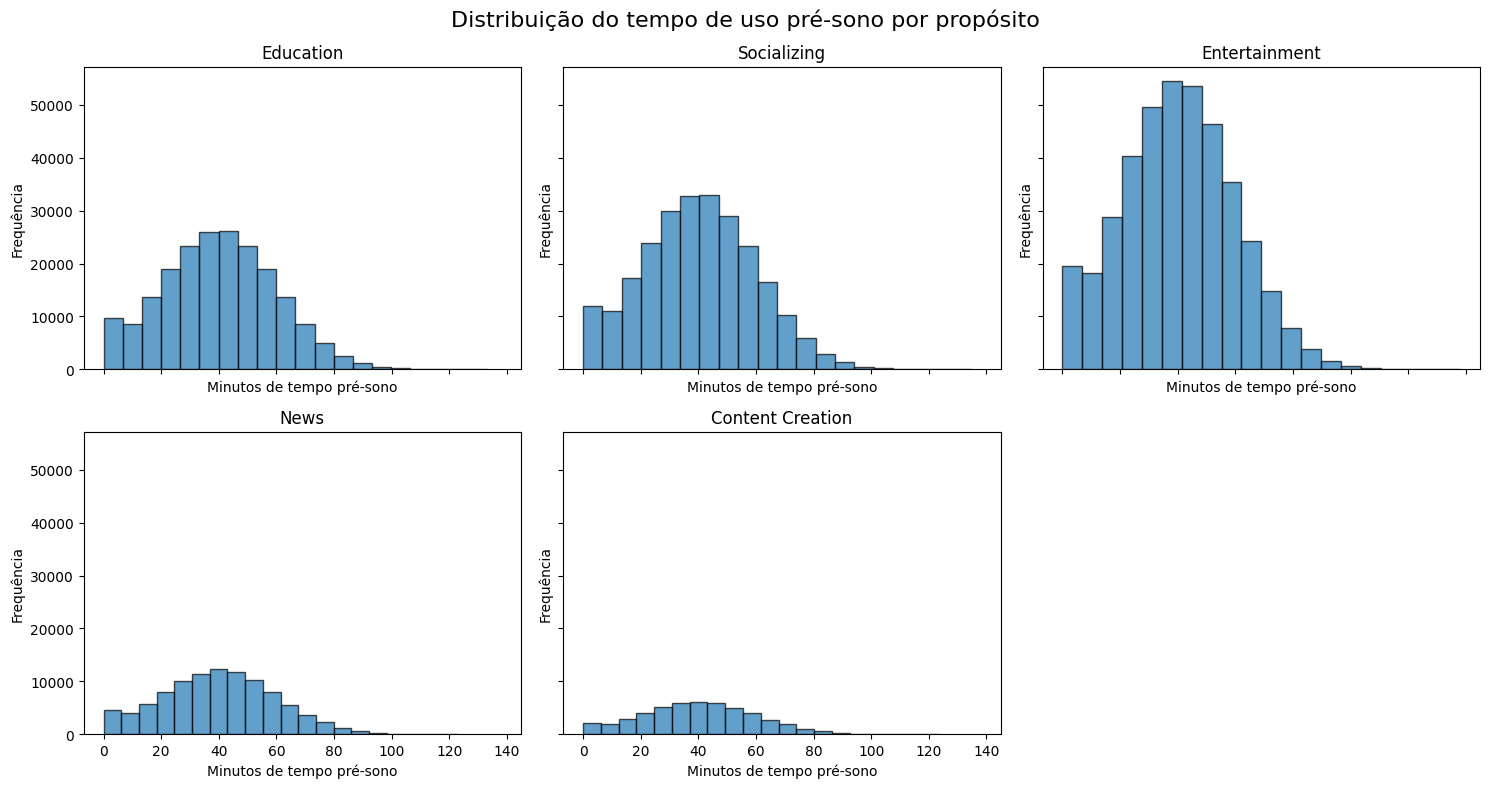

In [63]:
# Visualização da distribuição do uso diário de horas por plataforma em subplots

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (nome, df_plat) in enumerate(propositos):
    axes[i].hist(df_plat['screen_time_before_sleep'], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(nome)
    axes[i].set_xlabel('Minutos de tempo pré-sono')
    axes[i].set_ylabel('Frequência')

# Remover o sexto subplot que não é utilizado
fig.delaxes(axes[5])
    
plt.suptitle('Distribuição do tempo de uso pré-sono por propósito', fontsize=16)
plt.tight_layout()
plt.show()

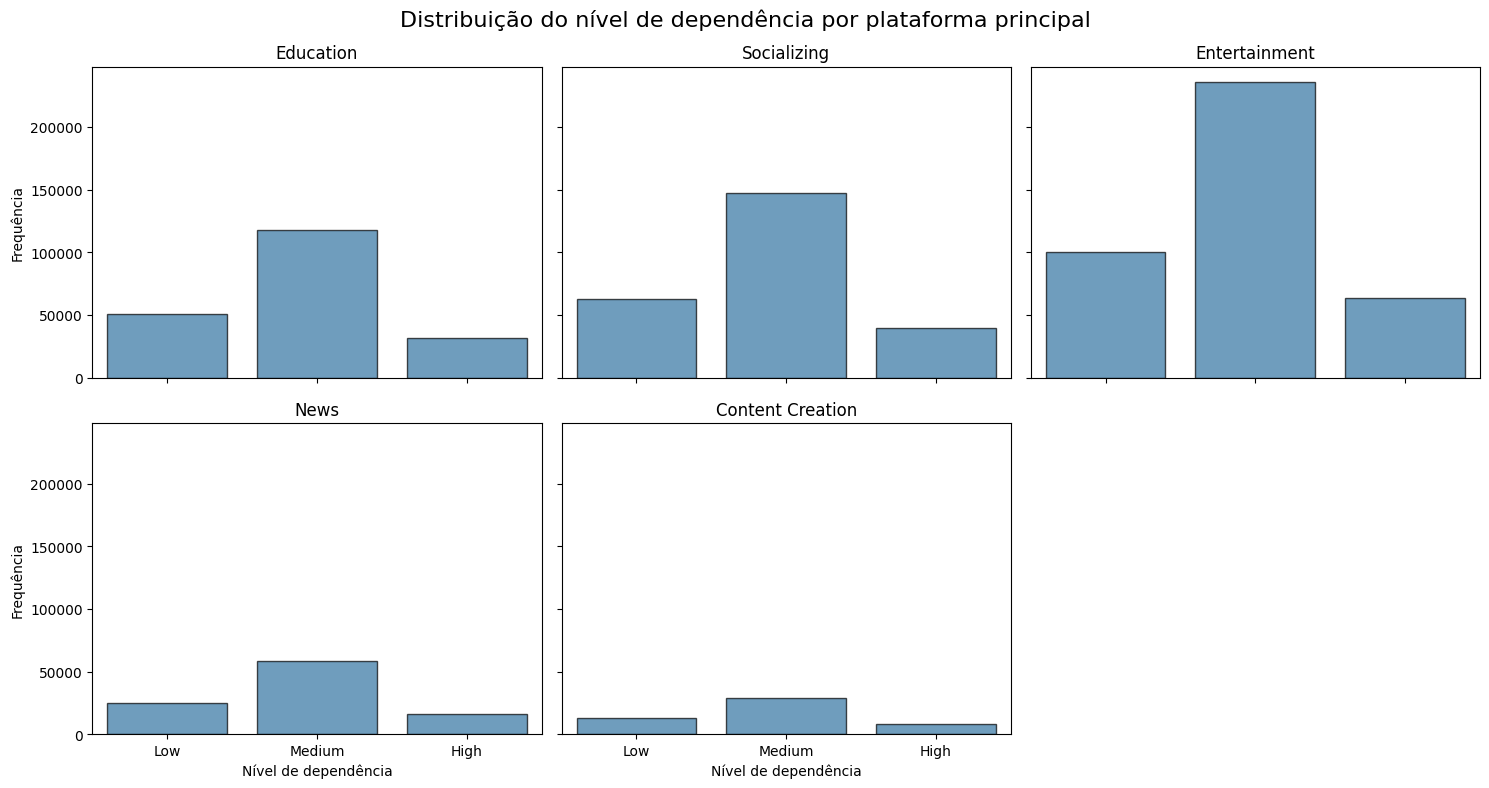

In [56]:
# Nível de dependência por plataforma 
ordem_addiction = ['Low', 'Medium', 'High']

fig, axes = plt.subplots(2, 3, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

for i, (nome, df_plat) in enumerate(propositos):
    sns.countplot(x='addiction_level', data=df_plat, order=ordem_addiction, edgecolor='black', alpha=0.7, ax=axes[i])
    axes[i].set_title(nome)
    axes[i].set_xlabel('Nível de dependência')
    axes[i].set_ylabel('Frequência')

fig.delaxes(axes[5])

plt.suptitle('Distribuição do nível de dependência por plataforma principal', fontsize=16)
plt.tight_layout()
plt.show()

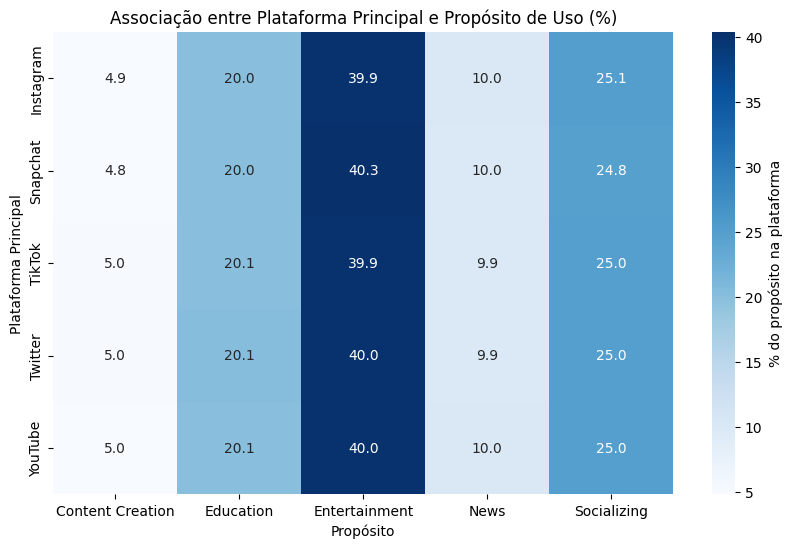

In [57]:
# Tabela de contingência percentual e Heatmap
crosstab_prop = pd.crosstab(df['primary_platform'], df['purpose'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_prop, annot=True, fmt='.1f', cmap='Blues', cbar_kws={'label': '% do propósito na plataforma'})
plt.title('Associação entre Plataforma Principal e Propósito de Uso (%)')
plt.ylabel('Plataforma Principal')
plt.xlabel('Propósito')
plt.show()

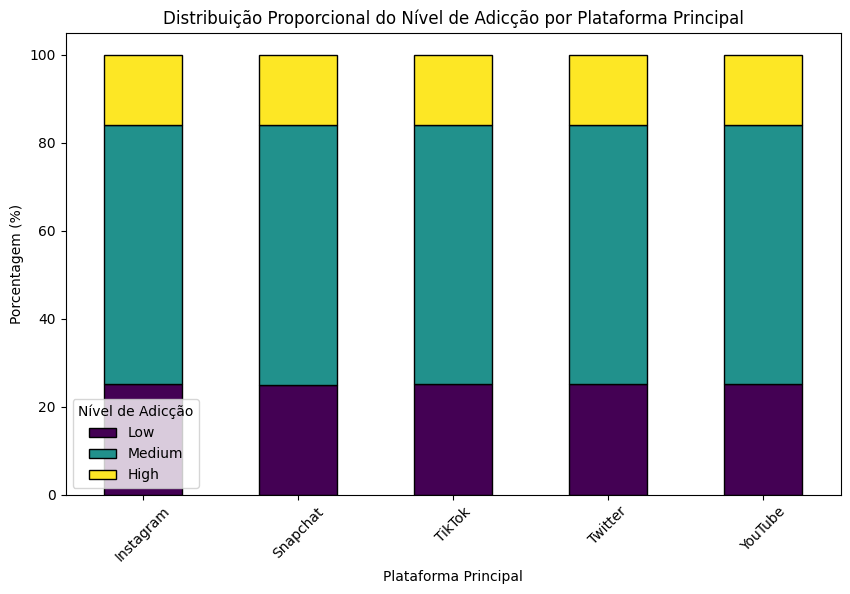

In [59]:
crosstab_addiction = pd.crosstab(df['primary_platform'], df['addiction_level'], normalize='index')[['Low', 'Medium', 'High']] * 100

crosstab_addiction.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis', edgecolor='black')
plt.title('Distribuição Proporcional do Nível de Adicção por Plataforma Principal')
plt.ylabel('Porcentagem (%)')
plt.xlabel('Plataforma Principal')
plt.legend(title='Nível de Adicção')
plt.xticks(rotation=45)
plt.show()